# Dia 1 · Módulo 2 — Variabilidade e Dispersão
### Estatística Básica Aplicada · Python

No Módulo 1 fechamos com uma promessa: *dois pelotões podem ter exatamente a mesma média e a
mesma mediana e ainda assim serem completamente diferentes*. Vamos cumprir essa promessa na
primeira célula — e depois responder às perguntas que ninguém costuma responder:

> ## Por que o desvio padrão eleva ao quadrado em vez de usar o módulo?
> ## Por que dividir por n − 1?
> ## E por que a decisão do comando quase nunca está no centro, e sim na cauda?

**O que a turma vai levar deste módulo:**
1. A soma dos desvios em torno da média é **sempre zero** — e é por isso que a variância existe.
2. Desvio absoluto e desvio padrão nascem das **mesmas duas réguas de erro** do Módulo 1.
3. O desvio padrão venceu por uma razão concreta: **variâncias se somam**. Daí sai a regra do **√n**.
4. O `n − 1` não é superstição: dá para **ver o viés** numa simulação, e ver que ele corrige a
   variância — **mas não corrige o desvio padrão**.
5. **Desvio padrão ≠ erro padrão.** Um descreve os militares, o outro descreve a sua estimativa.

> ⚠️ Você não precisa escrever código do zero: **ler → prever → rodar → interpretar → modificar**.

In [1]:
# --- Preparação do ambiente ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Mesma paleta do Módulo 1: cada CONCEITO mantém a MESMA cor em todo o curso.
COR = {
    "media":   "#2a78d6",   # azul
    "mediana": "#eb6834",   # laranja
    "moda":    "#1baf7a",   # verde-água
    "aparada": "#4a3aa7",   # violeta
    "dados":   "#9ec5f4",   # azul claro
    "alfa":    "#2a78d6",   # Pelotão Alfa
    "bravo":   "#eb6834",   # Pelotão Bravo
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "lines.linewidth": 2, "figure.dpi": 110,
})

print("Ambiente pronto.")

Ambiente pronto.


---
# ⓪ A promessa do Módulo 1

Dois pelotões fizeram a corrida de 3 km. Aqui estão os tempos, militar por militar.

In [2]:
# --- Dois pelotões, 12 militares cada ---
alfa  = np.array([13.1, 13.2, 13.3, 13.4, 13.4, 13.5, 13.5, 13.6, 13.6, 13.7, 13.8, 13.9])
bravo = np.array([11.2, 11.5, 11.8, 12.1, 12.4, 13.0, 14.0, 14.6, 15.0, 15.4, 15.5, 15.5])

print(f"{'':<10} | {'média':>7} | {'mediana':>8} | {'mínimo':>7} | {'máximo':>7}")
print("-" * 52)
for nome, x in [("ALFA", alfa), ("BRAVO", bravo)]:
    print(f"{nome:<10} | {x.mean():>7.2f} | {np.median(x):>8.2f} | {x.min():>7.2f} | {x.max():>7.2f}")

print("\nMesma média. Mesma mediana. E agora a pergunta que decide a missão:")
print("a operação exige que TODOS cheguem em até 14,0 min. Qual pelotão você emprega?\n")
for nome, x in [("ALFA", alfa), ("BRAVO", bravo)]:
    print(f"  {nome:<6}: {np.sum(x > 14.0)} militares acima de 14,0 min")

           |   média |  mediana |  mínimo |  máximo
----------------------------------------------------
ALFA       |   13.50 |    13.50 |   13.10 |   13.90
BRAVO      |   13.50 |    13.50 |   11.20 |   15.50

Mesma média. Mesma mediana. E agora a pergunta que decide a missão:
a operação exige que TODOS cheguem em até 14,0 min. Qual pelotão você emprega?

  ALFA  : 0 militares acima de 14,0 min
  BRAVO : 5 militares acima de 14,0 min


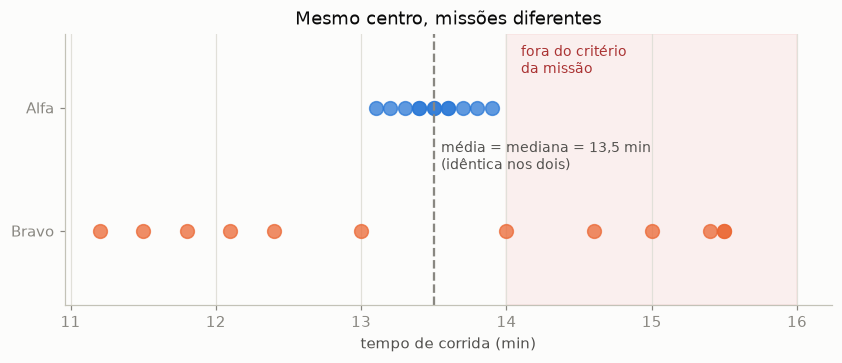

In [3]:
# --- Os mesmos números, vistos de lado ---
fig, ax = plt.subplots(figsize=(9, 3.2))

ax.plot(alfa,  np.full(12, 1), "o", color=COR["alfa"],  markersize=9, alpha=0.75, label="Pelotão Alfa")
ax.plot(bravo, np.full(12, 0), "o", color=COR["bravo"], markersize=9, alpha=0.75, label="Pelotão Bravo")
ax.axvline(13.5, color="#898781", linestyle="--", linewidth=1.5)
ax.annotate("média = mediana = 13,5 min\n(idêntica nos dois)", xy=(13.55, 0.5),
            color="#52514e", fontsize=9)
ax.axvspan(14.0, 16.0, color="#e34948", alpha=0.07)
ax.annotate("fora do critério\nda missão", xy=(14.1, 1.28), color="#a33", fontsize=9)

ax.set_yticks([0, 1], ["Bravo", "Alfa"])
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("tempo de corrida (min)")
ax.set_title("Mesmo centro, missões diferentes", color="#0b0b0b")
ax.grid(axis="y", visible=False)
plt.show()

> ### 🔑 A ideia central do módulo
> Uma medida de centro responde **"onde o grupo está"**. Quase nenhuma decisão operacional
> depende só disso. O que decide é **"quanto o grupo se espalha"** — porque é o espalhamento
> que diz quantos ficam de fora, quanto de folga planejar e qual o pior caso plausível.
>
> Reportar a média sem a dispersão não é um resumo incompleto. É uma **mentira por omissão**.

---
# ① Por que a variância precisou ser inventada

A ideia mais natural do mundo: dispersão = "distância média até a média". Vamos tentar.

In [4]:
# --- A tentativa ingênua: somar os desvios em relação à média ---
desvios_alfa  = alfa  - alfa.mean()
desvios_bravo = bravo - bravo.mean()

print("Desvios do Pelotão BRAVO (o mais espalhado dos dois):")
print(np.round(desvios_bravo, 2))
print()
print(f"Soma dos desvios · ALFA : {desvios_alfa.sum():.10f}")
print(f"Soma dos desvios · BRAVO: {desvios_bravo.sum():.10f}")
print()
print("Zero nos dois. E não é coincidência dos dados — é zero SEMPRE, para qualquer conjunto.")

Desvios do Pelotão BRAVO (o mais espalhado dos dois):
[-2.3 -2.  -1.7 -1.4 -1.1 -0.5  0.5  1.1  1.5  1.9  2.   2. ]

Soma dos desvios · ALFA : 0.0000000000
Soma dos desvios · BRAVO: 0.0000000000

Zero nos dois. E não é coincidência dos dados — é zero SEMPRE, para qualquer conjunto.


### Por que dá zero — e por que isso é boa notícia

Lembre do Módulo 1: a média é o ponto que **minimiza a soma dos erros ao quadrado**. Em um
ponto de mínimo, o "empurra pra cima" e o "empurra pra baixo" se cancelam exatamente — e esse
cancelamento **é** a soma dos desvios valendo zero. As duas coisas são o mesmo fato.

A média é o ponto de equilíbrio da amostra. Se você a apoiasse numa gangorra, ela ficaria plana.

Ou seja: a informação de dispersão está lá, mas o **sinal** dos desvios a destrói na soma.
Precisamos matar o sinal. Existem exatamente duas maneiras razoáveis — e são as **mesmas duas
réguas de erro** do Módulo 1:

| Régua | Como mata o sinal | Medida que nasce daí | Companheira do Módulo 1 |
|---|---|---|---|
| **L1** | `\|desvio\|` (módulo) | **desvio absoluto médio** | mediana |
| **L2** | `desvio²` (quadrado) | **variância** e **desvio padrão** | média |

O curso inteiro de estatística clássica é construído sobre a segunda linha. A próxima seção
explica por quê — e não é porque a primeira seja errada.

In [5]:
# --- As duas maneiras de matar o sinal ---
def desvio_absoluto_medio(x):
    return np.mean(np.abs(x - x.mean()))          # régua L1

def desvio_padrao(x):
    return np.sqrt(np.mean((x - x.mean()) ** 2))  # régua L2 (por enquanto, dividindo por n)

print(f"{'':<10} | {'desv. absoluto':>15} | {'desvio padrão':>14}")
print("-" * 46)
for nome, x in [("ALFA", alfa), ("BRAVO", bravo)]:
    print(f"{nome:<10} | {desvio_absoluto_medio(x):>15.3f} | {desvio_padrao(x):>14.3f}")

print("\nAs duas contam a mesma história (Bravo é ~7x mais espalhado).")
print("As duas estão em MINUTOS — a mesma unidade dos dados. Isso vale para as duas.")
print("\nRepare: o desvio padrão é sempre um pouco MAIOR que o absoluto. Por quê?")
print("Porque elevar ao quadrado dá peso extra aos desvios grandes — a mesma assimetria")
print("de tratamento que fazia a média ser sensível a extremos no Módulo 1.")

           |  desv. absoluto |  desvio padrão
----------------------------------------------
ALFA       |           0.183 |          0.227
BRAVO      |           1.500 |          1.605

As duas contam a mesma história (Bravo é ~7x mais espalhado).
As duas estão em MINUTOS — a mesma unidade dos dados. Isso vale para as duas.

Repare: o desvio padrão é sempre um pouco MAIOR que o absoluto. Por quê?
Porque elevar ao quadrado dá peso extra aos desvios grandes — a mesma assimetria
de tratamento que fazia a média ser sensível a extremos no Módulo 1.


---
# ② Por que o desvio padrão venceu

O desvio absoluto médio é mais intuitivo ("distância média até o centro" é uma frase que qualquer
um entende). Mesmo assim, o mundo inteiro usa o desvio padrão. Três razões concretas.

## 2.1 · A razão decisiva: **variâncias se somam**

Uma patrulha percorre 4 trechos. Cada trecho tem o seu tempo médio e a sua variabilidade.
Qual a variabilidade do **tempo total**?

Se os trechos forem independentes, a resposta é limpa:

> **Var(total) = Var(trecho₁) + Var(trecho₂) + … + Var(trecho₄)**

Nada parecido vale para o desvio absoluto. Essa propriedade única é o que permite **propagar
incerteza** — de trechos para a patrulha, de peças para o conjunto, de etapas para o projeto.

In [6]:
# --- Simulando 50.000 patrulhas de 4 trechos independentes ---
rng = np.random.default_rng(1)
N = 50_000

trechos = [
    ("mata",   18.0, 3.0),   # (nome, tempo médio, desvio padrão) em minutos
    ("estrada", 9.0, 1.0),
    ("vau",     6.0, 2.0),
    ("subida", 22.0, 4.0),
]

tempos = np.column_stack([rng.normal(m, s, N) for _, m, s in trechos])
total = tempos.sum(axis=1)

soma_das_variancias = sum(s ** 2 for _, _, s in trechos)

print(f"variância do TOTAL (simulada) .....: {total.var(ddof=1):>8.3f}")
print(f"soma das variâncias dos trechos ...: {soma_das_variancias:>8.3f}   <- bate ✅")
print()
print(f"desvio padrão do TOTAL (simulado) .: {total.std(ddof=1):>8.3f} min")
print(f"soma dos desvios padrão dos trechos: {sum(s for _, _, s in trechos):>8.3f} min   <- NÃO é assim ❌")
print(f"raiz da soma das variâncias .......: {np.sqrt(soma_das_variancias):>8.3f} min   <- é assim ✅")
print()
print("Desvios padrão NÃO se somam. Variâncias sim. Por isso a variância é a moeda")
print("de troca da estatística, e o desvio padrão é só ela traduzida de volta para minutos.")

variância do TOTAL (simulada) .....:   30.189
soma das variâncias dos trechos ...:   30.000   <- bate ✅

desvio padrão do TOTAL (simulado) .:    5.494 min
soma dos desvios padrão dos trechos:   10.000 min   <- NÃO é assim ❌
raiz da soma das variâncias .......:    5.477 min   <- é assim ✅

Desvios padrão NÃO se somam. Variâncias sim. Por isso a variância é a moeda
de troca da estatística, e o desvio padrão é só ela traduzida de volta para minutos.


### A consequência prática: a **regra do √n**

Se você repete **n** etapas parecidas e independentes, o tempo total cresce com **n**, mas o
espalhamento do total cresce só com **√n**. Em outras palavras: **quanto mais etapas, mais
previsível fica o total, em termos relativos**. É por isso que planejar uma operação longa é
proporcionalmente menos arriscado que planejar uma única etapa curta.

In [8]:
# --- Somando n etapas idênticas e independentes ---
rng = np.random.default_rng(3)
etapas = [1, 2, 4, 9, 16, 25, 100] #numero de etapas

print(f"{'n etapas':>9} | {'média total':>12} | {'desvio total':>13} | {'desvio/√n':>10} | {'coef variação %':>11}")
print("-" * 68)
for n in etapas:
    soma = rng.normal(10.0, 2.0, size=(20_000, n)).sum(axis=1)
    print(f"{n:>9} | {soma.mean():>12.2f} | {soma.std(ddof=1):>13.2f} | "
          f"{soma.std(ddof=1) / np.sqrt(n):>10.2f} | {soma.std(ddof=1) / soma.mean() * 100:>10.1f}%")

print("\nColuna 'desvio/√n' fica travada em 2,0 — o desvio padrão da UMA etapa, ou seja quando a amostra = 1")
print("Ou seja: desvio do total = 2,0 × √n. Cresce, mas devagar.")
print("Coluna 'variação %': o total fica RELATIVAMENTE mais previsível a cada etapa somada.")

 n etapas |  média total |  desvio total |  desvio/√n | coef variação %
--------------------------------------------------------------------
        1 |        10.01 |          1.99 |       1.99 |       19.9%
        2 |        20.02 |          2.81 |       1.99 |       14.0%
        4 |        39.99 |          4.00 |       2.00 |       10.0%
        9 |        89.99 |          6.00 |       2.00 |        6.7%
       16 |       160.06 |          8.00 |       2.00 |        5.0%
       25 |       250.01 |         10.05 |       2.01 |        4.0%
      100 |       999.53 |         20.22 |       2.02 |        2.0%

Coluna 'desvio/√n' fica travada em 2,0 — o desvio padrão da UMA etapa, ou seja quando a amostra = 1
Ou seja: desvio do total = 2,0 × √n. Cresce, mas devagar.
Coluna 'variação %': o total fica RELATIVAMENTE mais previsível a cada etapa somada.


para um n=3, teríamos

linha 1: X1=11.2, Y1=8.7,  Z1=10.4   → soma = 30.3

linha 2: X1=9.1,  Y1=12.3, Z1=9.8    → soma = 31.2

linha 3: X1=10.5, Y1=9.9,  Z1=8.6    → soma = 29.0

Vamos ver mais tarde que cada linha dessa será comparada a nossa amostra!

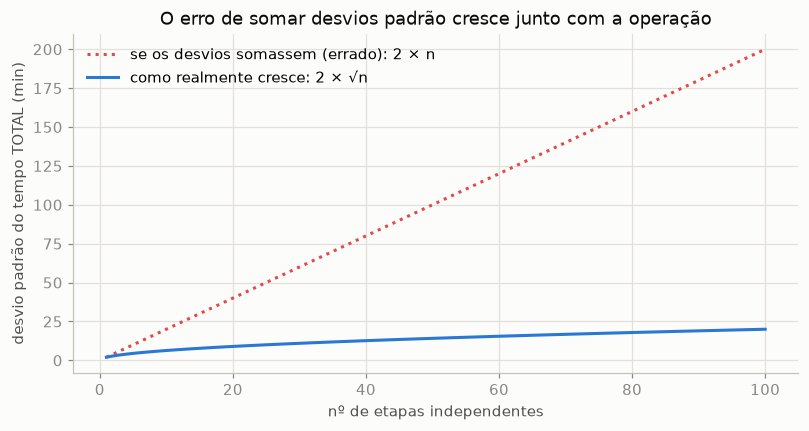

Com 100 etapas, somar os desvios daria 200 min de incerteza; o real é 20 min.
Planejar pela conta errada significa imobilizar tropa e pista por uma folga que não existe.


In [8]:
# --- O mesmo fato, em gráfico: como o espalhamento cresce com o nº de etapas ---
n_etapas = np.arange(1, 101)

plt.figure(figsize=(8.5, 4))
plt.plot(n_etapas, 2.0 * n_etapas, color="#e34948", linestyle=":",
         label="se os desvios somassem (errado): 2 × n")
plt.plot(n_etapas, 2.0 * np.sqrt(n_etapas), color=COR["media"],
         label="como realmente cresce: 2 × √n")
plt.title("O erro de somar desvios padrão cresce junto com a operação", color="#0b0b0b")
plt.xlabel("nº de etapas independentes")
plt.ylabel("desvio padrão do tempo TOTAL (min)")
plt.legend(frameon=False)
plt.show()

print("Com 100 etapas, somar os desvios daria 200 min de incerteza; o real é 20 min.")
print("Planejar pela conta errada significa imobilizar tropa e pista por uma folga que não existe.")

Ou seja, se pensarmos em comida, se eu olhar a variabilidade do consumo (como desvio padrao) de cada OM e somar essas margens para estimar quanto eu preciso ter de folga para alimentar toda a brigada, você estará superestimando essa folga se não considerar a raiz da quantidade de OM.

A ressalva que precisa ficar clara: isso só vale se as variações forem independentes (ou quase). É aqui que a logística real pode fugir do modelo idealizado. Se o consumo das OMs varia por razões comuns a todas — por exemplo, um dia muito quente, um feriado, um exercício conjunto que aumenta o apetite de toda a brigada ao mesmo tempo, ou um problema no fornecimento que afeta todas juntas — as variações deixam de ser independentes e passam a ser correlacionadas. Quando isso acontece, o efeito de cancelamento (uma OM consumindo menos compensando outra consumindo mais) desaparece, e a incerteza real do total se aproxima mais da soma direta dos desvios (o caso "ruim", σ×n) do que da versão com √n.

Na prática: o √n é o limite otimista (variações totalmente independentes) e a soma direta é o limite pessimista (variações totalmente correlacionadas, todas na mesma direção ao mesmo tempo). A realidade da logística militar provavelmente fica entre os dois — hoje há alguma correlação real (clima, calendário, operações conjuntas), mas nem toda a variação é comum a todas as OMs. Então na hora de planejar, vale usar o √n como referência de quanto você poderia economizar de folga, mas com cautela, sabendo que ele pressupõe independência que talvez não exista 100% no mundo real.

Exemplo com números, usando sua ideia das OMs: suponha 10 OMs, cada uma consumindo em média 500 refeições/dia, com desvio padrão de 50 refeições/dia (independentes entre si).

- Total esperado = 10 × 500 = 5000 refeições
- Desvio "errado" (soma direta): 10 × 50 = 500
- Desvio correto (√n, assumindo independência): 50 × √10 ≈ 158

## 2.2 · A segunda razão: precisão

Mesmo argumento do Módulo 1, §2.3 — só que agora aplicado à dispersão. Em dados bem comportados,
o desvio padrão estima a variabilidade real com **menos erro** que o desvio absoluto.

## 2.3 · E a desvantagem, que é grande

O desvio padrão herda da média toda a fragilidade a valores extremos — na verdade **piora**,
porque eleva os desvios ao quadrado. Um único erro de digitação destrói a estimativa.

As versões robustas, para quando isso importa:
- **IQR** (distância entre o 1º e o 3º quartil) — o "desvio padrão da mediana";
- **MAD** (mediana dos desvios absolutos em torno da mediana), multiplicado por **1,4826** para
  ficar na mesma escala do desvio padrão em dados normais.

In [9]:
# --- O que UM erro de digitação faz com cada medida ---
def mad_robusto(x):
    return 1.4826 * np.median(np.abs(x - np.median(x)))

def iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

com_erro = bravo.copy()
com_erro[0] = 112.0        # digitaram 112 em vez de 11.2

print(f"{'medida':<22} | {'original':>9} | {'com erro':>9} | {'variação':>9}")
print("-" * 58)
for nome, funcao in [("desvio padrão", lambda x: x.std(ddof=1)),
                     ("desvio absoluto médio", desvio_absoluto_medio),
                     ("IQR", iqr),
                     ("MAD × 1,4826", mad_robusto)]:
    a, b = funcao(bravo), funcao(com_erro)
    print(f"{nome:<22} | {a:>9.2f} | {b:>9.2f} | {(b / a - 1) * 100:>8.0f}%")

print("\nUm dígito a mais em UM militar multiplica o desvio padrão por ~17.")
print("O IQR não se move. O MAD muda 22% — e isso tem explicação: o valor corrompido")
print("era o MAIS BAIXO do pelotão e virou o mais alto, então a própria mediana andou.")
print("Ainda assim, compare as ordens de grandeza: 22% contra 1.595%.")
print("\nMesma lição do Módulo 1: robustez é uma ESCOLHA, e ela custa precisão")
print("quando os dados estão limpos. Não existe medida que só tenha vantagens.")

medida                 |  original |  com erro |  variação
----------------------------------------------------------
desvio padrão          |      1.68 |     28.41 |     1595%
desvio absoluto médio  |      1.50 |     15.02 |      901%
IQR                    |      3.07 |      3.10 |        1%
MAD × 1,4826           |      2.37 |      1.85 |      -22%

Um dígito a mais em UM militar multiplica o desvio padrão por ~17.
O IQR não se move. O MAD muda 22% — e isso tem explicação: o valor corrompido
era o MAIS BAIXO do pelotão e virou o mais alto, então a própria mediana andou.
Ainda assim, compare as ordens de grandeza: 22% contra 1.595%.

Mesma lição do Módulo 1: robustez é uma ESCOLHA, e ela custa precisão
quando os dados estão limpos. Não existe medida que só tenha vantagens.


---
# ③ Por que dividir por n − 1

Esta é a pergunta que todo aluno faz e que quase sempre recebe a resposta "é uma correção, aceite".
Dá para **ver** o problema acontecendo.

**O raciocínio:** para medir o espalhamento você precisa de um ponto de referência. Você usa a
média **da própria amostra** — e essa média foi puxada na direção dos dados que você tem. Ela é o
ponto que **minimiza** a soma dos quadrados daquela amostra (Módulo 1!), ou seja, **nenhum outro
ponto daria uma soma menor** — inclusive a média verdadeira da população, que você não conhece.

Resultado: os desvios que você calcula são sistematicamente **pequenos demais**. Você subestima
a variabilidade. Sempre. Vamos medir esse "sempre".

In [10]:
# --- Simulação: 40.000 pelotões sorteados de uma população com σ CONHECIDO ---
rng = np.random.default_rng(5)
SIGMA_REAL, MU_REAL, N_MIL, N_SIM = 2.0, 13.0, 5, 40_000

amostras = rng.normal(MU_REAL, SIGMA_REAL, size=(N_SIM, N_MIL))

var_n    = amostras.var(axis=1, ddof=0)   # dividindo por n
var_n1   = amostras.var(axis=1, ddof=1)   # dividindo por n-1
# se conhecêssemos a média verdadeira da população, não haveria problema nenhum:
var_ideal = np.mean((amostras - MU_REAL) ** 2, axis=1)

print(f"Variância VERDADEIRA da população: {SIGMA_REAL ** 2:.4f}\n")
print(f"{'estimador':<34} | {'média das estimativas':>21}")
print("-" * 60)
print(f"{'usando a média VERDADEIRA (÷ n)':<34} | {var_ideal.mean():>21.4f}")
print(f"{'usando a média da amostra (÷ n)':<34} | {var_n.mean():>21.4f}   <- subestima")
print(f"{'usando a média da amostra (÷ n-1)':<34} | {var_n1.mean():>21.4f}   <- corrigido ✅")
print()
print(f"O erro do primeiro caso não é aleatório: é exatamente o fator (n-1)/n = {(N_MIL-1)/N_MIL:.2f}.")
print(f"Confira: {SIGMA_REAL**2:.4f} × {(N_MIL-1)/N_MIL:.2f} = {SIGMA_REAL**2 * (N_MIL-1)/N_MIL:.4f}")

Variância VERDADEIRA da população: 4.0000

estimador                          | média das estimativas
------------------------------------------------------------
usando a média VERDADEIRA (÷ n)    |                4.0105
usando a média da amostra (÷ n)    |                3.2141   <- subestima
usando a média da amostra (÷ n-1)  |                4.0177   <- corrigido ✅

O erro do primeiro caso não é aleatório: é exatamente o fator (n-1)/n = 0.80.
Confira: 4.0000 × 0.80 = 3.2000


ou seja, para corrigir basta multiplicar o valor da variancia amostral(dividida por n) pelo fator (n)/(n-1) 

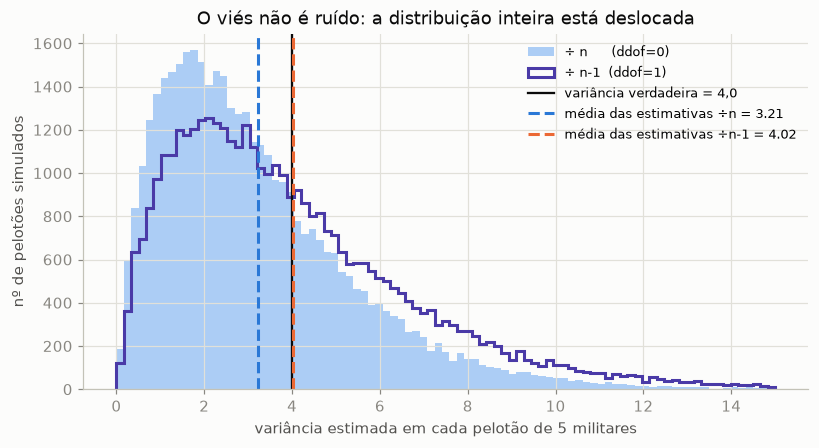

As duas distribuições são MUITO espalhadas — com n=5 qualquer estimativa isolada erra feio.
A diferença é que a de cima está centrada no lugar certo e a outra não.
Viés é isso: um erro que NÃO some por mais que você repita a medição.


In [11]:
# --- O viés, visto de uma vez: 40.000 estimativas de cada jeito ---
plt.figure(figsize=(8.5, 4.2))
faixas = np.linspace(0, 15, 90)
plt.hist(var_n,  bins=faixas, color=COR["dados"],   alpha=0.85, label="÷ n      (ddof=0)")
plt.hist(var_n1, bins=faixas, histtype="step", linewidth=2, color=COR["aparada"], label="÷ n-1  (ddof=1)")
plt.axvline(SIGMA_REAL ** 2, color="#0b0b0b", linewidth=1.5, label="variância verdadeira = 4,0")
plt.axvline(var_n.mean(),  color=COR["media"],   linestyle="--", label=f"média das estimativas ÷n = {var_n.mean():.2f}")
plt.axvline(var_n1.mean(), color=COR["mediana"], linestyle="--", label=f"média das estimativas ÷n-1 = {var_n1.mean():.2f}")
plt.title("O viés não é ruído: a distribuição inteira está deslocada", color="#0b0b0b")
plt.xlabel("variância estimada em cada pelotão de 5 militares")
plt.ylabel("nº de pelotões simulados")
plt.legend(frameon=False, fontsize=8.5)
plt.show()

print("As duas distribuições são MUITO espalhadas — com n=5 qualquer estimativa isolada erra feio.")
print("A diferença é que a de cima está centrada no lugar certo e a outra não.")
print("Viés é isso: um erro que NÃO some por mais que você repita a medição.")

### Graus de liberdade, sem misticismo

Outra forma de ver a mesma coisa. Você tem `n` desvios, mas eles **não são livres**: já sabemos
que a soma deles é zero (§1). Se você me contar `n − 1` deles, eu deduzo o último. Só existem
`n − 1` informações independentes ali dentro. Por isso a divisão.

O caso extremo torna isso óbvio: com **n = 2**, os desvios são sempre `+d` e `−d`. Dois números,
uma informação só.

In [11]:
# --- n = 2: dois desvios, uma informação ---
for dupla in [np.array([12.0, 14.0]), np.array([13.4, 13.6]), np.array([10.0, 20.0])]:
    d = dupla - dupla.mean()
    print(f"dados {dupla}  ->  desvios {d}   (sempre +d e -d)")

print("\nCom n=2, dividir por n=2 é dividir a informação pela metade sem motivo.")
print("Dividir por n-1 = 1 é o correto: existe exatamente 1 desvio livre.")

dados [12. 14.]  ->  desvios [-1.  1.]   (sempre +d e -d)
dados [13.4 13.6]  ->  desvios [-0.1  0.1]   (sempre +d e -d)
dados [10. 20.]  ->  desvios [-5.  5.]   (sempre +d e -d)

Com n=2, dividir por n=2 é dividir a informação pela metade sem motivo.
Dividir por n-1 = 1 é o correto: existe exatamente 1 desvio livre.


### 💡 O detalhe honesto que quase ninguém conta

O `n − 1` corrige a **variância**. Ele **não** corrige o **desvio padrão**.

Motivo: a raiz quadrada é uma função curva, e a média de uma raiz não é a raiz da média. Mesmo
com `ddof=1`, o desvio padrão amostral ainda **subestima** o desvio padrão da população — pouco,
mas sistematicamente, e mais quanto menor a amostra.

Ninguém corrige isso na prática (o viés é pequeno e some rápido com n), mas você deve **saber
que ele existe** antes de tirar conclusões finas de amostras minúsculas.

In [13]:
# --- O viés que sobra no desvio padrão, mesmo com ddof=1 ---
print(f"Desvio padrão VERDADEIRO da população: {SIGMA_REAL:.4f}\n")
print(f"{'n':>4} | {'média do s (ddof=1)':>20} | {'viés':>8}")
print("-" * 38)
for n in [3, 5, 10, 30, 100]:
    s = rng.normal(MU_REAL, SIGMA_REAL, size=(40_000, n)).std(axis=1, ddof=1)
    print(f"{n:>4} | {s.mean():>20.4f} | {(s.mean() / SIGMA_REAL - 1) * 100:>7.1f}%")

print("\nA VARIÂNCIA com ddof=1 é certeira. O DESVIO PADRÃO ainda fica curto —")
print("~6% com n=5, ~0,3% com n=100. Some rápido, mas não é zero.")

Desvio padrão VERDADEIRO da população: 2.0000

   n |  média do s (ddof=1) |     viés
--------------------------------------
   3 |               1.7704 |   -11.5%
   5 |               1.8768 |    -6.2%
  10 |               1.9479 |    -2.6%


  30 |               1.9807 |    -1.0%


 100 |               1.9952 |    -0.2%

A VARIÂNCIA com ddof=1 é certeira. O DESVIO PADRÃO ainda fica curto —
~6% com n=5, ~0,3% com n=100. Some rápido, mas não é zero.


### ⚠️ Armadilha de Python que você VAI encontrar

`numpy` e `pandas` **não têm o mesmo padrão**:

| Ferramenta | `ddof` padrão | Ou seja |
|---|---|---|
| `np.std(x)` / `np.var(x)` | **0** | divide por `n` |
| `pandas: serie.std()` | **1** | divide por `n − 1` |

Os mesmos dados, dois números diferentes, nenhum erro de sintaxe. É a origem de uma quantidade
absurda de relatórios divergentes. **Explicite sempre o `ddof`.**

In [12]:
# --- A mesma coluna, duas bibliotecas, dois números ---
serie = pd.Series(bravo)

print(f"np.std(bravo)          = {np.std(bravo):.4f}   (ddof=0, divide por n)")
print(f"pd.Series(bravo).std() = {serie.std():.4f}   (ddof=1, divide por n-1)")
print(f"\ndiferença: {(serie.std() / np.std(bravo) - 1) * 100:.1f}% — nos mesmos dados, sem erro nenhum de código.")
print("\nForma segura, que funciona nas duas: sempre escrever o ddof.")
print(f"  np.std(bravo, ddof=1)          = {np.std(bravo, ddof=1):.4f}")
print(f"  pd.Series(bravo).std(ddof=1)   = {serie.std(ddof=1):.4f}")

np.std(bravo)          = 1.6052   (ddof=0, divide por n)
pd.Series(bravo).std() = 1.6766   (ddof=1, divide por n-1)

diferença: 4.4% — nos mesmos dados, sem erro nenhum de código.

Forma segura, que funciona nas duas: sempre escrever o ddof.
  np.std(bravo, ddof=1)          = 1.6766
  pd.Series(bravo).std(ddof=1)   = 1.6766


---
# ④ Transformando dispersão em decisão

Ter o número é fácil. As três perguntas abaixo são o que transforma o número em ordem de operação.

## 4.1 · "É muito ou é pouco?" — coeficiente de variação

Um desvio padrão de 1,7 min é grande? Depende do que está sendo medido. O **coeficiente de
variação** (CV = desvio padrão ÷ média) responde em **porcentagem**, o que permite comparar
variáveis de unidades diferentes: tempo com flexões, peso com distância.

**Cuidado:** só faz sentido em escalas com **zero absoluto** (tempo, peso, contagem). Em
temperatura em °C o CV é uma conta sem significado, porque o zero é arbitrário.

In [13]:
# --- Comparando a variabilidade de coisas diferentes ---
taf = pd.DataFrame({
    "tempo_corrida_min": bravo,
    "flexoes":           [42, 38, 45, 40, 38, 41, 38, 44, 39, 38, 43, 20],
    "peso_kg":           [78, 92, 71, 85, 80, 76, 88, 95, 69, 83, 79, 90],
})

print(f"{'variável':<20} | {'média':>8} | {'desvio':>8} | {'CV':>7}")
print("-" * 50)
for coluna in taf.columns:
    x = taf[coluna].to_numpy()
    print(f"{coluna:<20} | {x.mean():>8.2f} | {x.std(ddof=1):>8.2f} | {x.std(ddof=1)/x.mean()*100:>6.1f}%")

print("\nAgora dá para responder 'o que é mais heterogêneo neste pelotão?' —")
print("uma pergunta que os desvios padrão sozinhos (1,7 min contra 6,6 flexões) não respondem.")

variável             |    média |   desvio |      CV
--------------------------------------------------
tempo_corrida_min    |    13.50 |     1.68 |   12.4%
flexoes              |    38.83 |     6.44 |   16.6%
peso_kg              |    82.17 |     8.17 |    9.9%

Agora dá para responder 'o que é mais heterogêneo neste pelotão?' —
uma pergunta que os desvios padrão sozinhos (1,7 min contra 6,6 flexões) não respondem.


## 4.2 · "Quantos ficam de fora?" — Chebyshev × regra 68-95-99,7

Você tem média e desvio padrão. Quantos militares caem dentro de **±k desvios**?

Existem duas respostas, e a diferença entre elas é uma das mais úteis do curso:

| Regra | Diz o quê | Vale quando |
|---|---|---|
| **Chebyshev** | *pelo menos* `1 − 1/k²` dos dados | **sempre**, qualquer distribuição |
| **68-95-99,7** | ~68% em ±1σ, ~95% em ±2σ, ~99,7% em ±3σ | **só** se os dados forem aproximadamente normais |

Chebyshev é fraco (garante só 75% em ±2σ) mas é **inegociável**. A regra 68-95-99,7 é forte, é a
que todo mundo usa — e é a que **quebra silenciosamente** quando a distribuição é assimétrica.

In [14]:
# --- As duas regras, testadas em dados normais e em dados assimétricos ---
rng = np.random.default_rng(9)
N = 200_000

populacoes = {
    "normal (simétrica)":       rng.normal(13, 2, N),
    "assimétrica (lognormal)":  rng.lognormal(2.5, 0.8, N),
}

print(f"{'população':<26} | {'k':>2} | {'Chebyshev':>10} | {'68-95-99,7':>11} | {'REAL':>7}")
print("-" * 68)
for nome, x in populacoes.items():
    m, s = x.mean(), x.std(ddof=1)
    for k, normal in [(1, 68.3), (2, 95.4), (3, 99.7)]:
        dentro = np.mean(np.abs(x - m) <= k * s) * 100
        cheby = max(0.0, 1 - 1 / k ** 2) * 100
        print(f"{nome if k == 1 else '':<26} | {k:>2} | {cheby:>9.1f}% | {normal:>10.1f}% | {dentro:>6.1f}%")
    print("-" * 68)

print("(k=1 dá 0% em Chebyshev porque 1 - 1/1² = 0: ele simplesmente não garante nada aí.)")
print("Na normal, a regra 68-95-99,7 acerta em cheio e Chebyshev é folgado demais.")
print("Na assimétrica, a regra 68-95-99,7 ERRA — e Chebyshev continua válido.")
print("Só use 68-95-99,7 depois de olhar a forma da distribuição (Módulo 3).")

população                  |  k |  Chebyshev |  68-95-99,7 |    REAL
--------------------------------------------------------------------
normal (simétrica)         |  1 |       0.0% |       68.3% |   68.3%
                           |  2 |      75.0% |       95.4% |   95.4%
                           |  3 |      88.9% |       99.7% |   99.7%
--------------------------------------------------------------------
assimétrica (lognormal)    |  1 |       0.0% |       68.3% |   89.1%
                           |  2 |      75.0% |       95.4% |   95.9%
                           |  3 |      88.9% |       99.7% |   98.2%
--------------------------------------------------------------------
(k=1 dá 0% em Chebyshev porque 1 - 1/1² = 0: ele simplesmente não garante nada aí.)
Na normal, a regra 68-95-99,7 acerta em cheio e Chebyshev é folgado demais.
Na assimétrica, a regra 68-95-99,7 ERRA — e Chebyshev continua válido.
Só use 68-95-99,7 depois de olhar a forma da distribuição (Módulo 3).


É muito comum (especialmente em ambientes de negócios e engenharia) que as pessoas calculem a média e o desvio padrão de um conjunto de dados e assumam instantaneamente que a regra empírica (Normal) se aplica, sem desenhar o histograma para checar se a curva é um sino perfeito. Quando a distribuição é assimétrica, a regra Normal deixa de ser um teorema matemático e passa a ser apenas um "chute". O alerta do código é: o Chebyshev é frouxo, mas é um teorema matemático incontestável aplicável a qualquer conjunto de dados. A regra da Normal é precisa, mas só tem permissão para existir se a simetria for verdadeira. Se não for, usá-la é uma falha metodológica, independentemente de ela chegar perto do resultado por pura sorte.

Explicando melhor:

Com certeza. Para entender por que a regra do $k=2$ (95%) e $k=3$ (99,7%) falha na distribuição assimétrica, precisamos olhar para a **definição estrutural da Curva Normal**.

O "DNA" da Distribuição Normal é definido por uma característica inegociável: **a simetria perfeita em torno da média**.

Imagine que a média é um espelho. Se você andar 2 desvios padrões para a esquerda ($\mu - 2\sigma$), você encontrará **exatamente a mesma quantidade de dados** que encontraria andando 2 desvios padrões para a direita ($\mu + 2\sigma$). A mesma regra vale para $k=3$.

A Normal assume que o "risco" (os dados que ficam de fora) está perfeitamente dividido:

* Para $k=3$, a Normal jura que 99,7% dos dados estão no centro.
* Sobram 0,3% de fora.
* A definição da Normal **exige** que esses 0,3% sejam divididos no meio: 0,15% são valores extremamente pequenos (lado esquerdo) e 0,15% são valores extremamente grandes (lado direito).

**O problema de aplicar essa definição em dados assimétricos**

Quando você pega essa "janela" simétrica da Normal (que olha igual para os dois lados) e a joga em cima de dados assimétricos (como a Log-Normal, que tem uma cauda longa se arrastando para a direita), você cria duas grandes distorções em $k=2$ e $k=3$:

**1. O lado esquerdo procura dados onde não existe nada (Risco Fantasma)**

Nas distribuições assimétricas, os dados geralmente têm uma "parede" do lado esquerdo (por exemplo, tempo de execução de um código, salários, ou preços não podem ser menores que zero) e se acumulam perto dessa parede.

Como a cauda direita puxa a média para cima e infla o desvio padrão, quando você calcula $\mu - 2\sigma$ ou $\mu - 3\sigma$, a matemática da Normal te joga para **números negativos ou impossíveis**.
A Normal está "esperando" encontrar 0,15% dos seus dados lá nos números negativos, mas na vida real tem zero dados lá. Você desperdiçou parte da sua janela de 99,7% caçando fantasmas.

**2. O lado direito ignora o verdadeiro perigo (Ponto Cego)**

Como a janela da Normal gastou "espaço" caçando fantasmas do lado esquerdo, ela compensa isso do lado direito.
A fórmula $\mu + 3\sigma$ avança para a direita, mas não o suficiente para cobrir a longa cauda da distribuição assimétrica. A Normal acha que além do $\mu + 3\sigma$ só existe aquele restinho de 0,15% de dados.

Mas como a distribuição real é puxada para a direita, existe uma **massa enorme de dados reais** (1%, 2% ou até 3%) que vivem além desse ponto.

**Resumo do problema em $k=2$ e $k=3$**

A definição da Normal tenta colocar um "cobertor simétrico" em cima de uma "cama assimétrica".

Quando parece que a Normal quase acertou o número total (ex: previu 99,7% e deu 98,1% no $k=3$), o que está acontecendo por baixo dos panos é uma compensação trágica:

* Ela incluiu 100% dos dados normais do lado esquerdo (porque o cobertor sobrou e cobriu até o vazio).
* Ela deixou o pé de fora do lado direito (porque o cobertor não alcançou a cauda longa).

Em suma: o problema não é apenas que a regra erra a **quantidade total** de eventos (como vimos na diferença de 99,7% para 98,1%), mas ela **mente sobre ONDE o erro está**. Ela te diz que o risco de algo ser muito baixo é igual ao risco de algo ser muito alto, quando, numa distribuição assimétrica, o perigo de extrapolação mora quase inteiramente de um lado só.

## 4.3 · "Quanto planejar?" — a decisão está na cauda

Esta é a aplicação que fecha o módulo. O comando precisa reservar a pista para os 12 militares
do Pelotão Bravo. Quanto tempo pedir?

- Planejar pela **média** significa aceitar que **metade** vai estourar o prazo.
- Planejar pela **cauda** (média + k desvios, ou direto por um percentil alto) é o que se faz
  quando estourar custa caro.

In [15]:
# --- Dimensionando pelo centro × dimensionando pela cauda ---
m, s = bravo.mean(), bravo.std(ddof=1)

print(f"{'critério de planejamento':<34} | {'tempo':>7} | {'quantos estouram':>17}")
print("-" * 66)
for rotulo, limite in [
    ("média",                m),
    ("média + 1 desvio",     m + s),
    ("média + 2 desvios",    m + 2 * s),
    ("percentil 90 (direto dos dados)", np.percentile(bravo, 90)),
    ("máximo observado",     bravo.max()),
]:
    estouram = np.sum(bravo > limite)
    print(f"{rotulo:<34} | {limite:>6.2f}m | {estouram:>13} de 12")

#print("\nRepare que 'média + 2 desvios' e 'percentil 90' dão respostas diferentes.")
#print("O primeiro CONFIA que os dados são normais; o segundo lê direto o que aconteceu.")
#print("Com poucos dados o percentil é instável; com dados torcidos, a fórmula é que engana.")
#print("Reporte os dois quando a decisão for cara.")

critério de planejamento           |   tempo |  quantos estouram
------------------------------------------------------------------
média                              |  13.50m |             6 de 12
média + 1 desvio                   |  15.18m |             3 de 12
média + 2 desvios                  |  16.85m |             0 de 12
percentil 90 (direto dos dados)    |  15.49m |             2 de 12
máximo observado                   |  15.50m |             0 de 12


---
# ⑤ Desvio padrão **não** é erro padrão

Confusão nº 1 em relatórios técnicos. As duas coisas se parecem, têm a mesma unidade e respondem
a perguntas completamente diferentes:

| | Responde | O que acontece se você medir mais militares |
|---|---|---|
| **Desvio padrão (σ)** | quanto os **militares** diferem entre si | **nada** — ele é uma característica da tropa |
| **Erro padrão (σ/√n)** | quanto a **sua estimativa da média** balança | **diminui** — mais dados, estimativa mais firme |

Se você escreve "13,5 ± 1,7 min" sem dizer qual dos dois é, o leitor não sabe se 1,7 descreve a
tropa ou a sua ignorância.

Se você reserva a pista por 13,50 min (a média), veja o resultado: 6 dos 12 militares — metade — levam mais que isso e estouram o horário reservado. Isso não é coincidência nem falha de cálculo — é a própria natureza da média: ela é o "centro" dos dados, então (em dados razoavelmente simétricos) aproximadamente metade dos valores fica acima dela e metade abaixo, por definição. Planejar pela média é, na prática, dizer "estou apostando numa moeda: 50% de chance de cada militar estourar o prazo". Para uma estimativa de "quanto tempo típico leva", tudo bem. Mas como plano de reserva de recurso, é péssimo — você já sabe de antemão que metade vai falhar.

Se estourar o prazo tem consequência séria (pista fica ocupada além do previsto, atrasa a próxima aeronave, compromete o cronograma da operação), você não quer aceitar 50% de chance de falha. Então, em vez de mirar no centro da distribuição, você mira mais para a direita, na cauda — a região dos valores mais altos, mais raros.

Duas formas de fazer isso, mostradas na tabela:

1. Média + k desvios (ex.: média + 2 desvios = 16,85 min): pega o centro e soma "k vezes a dispersão típica". Com k=2, ninguém estourou (0 de 12) neste exemplo. Essa conta presume que os dados seguem aproximadamente uma distribuição normal — é uma fórmula, uma extrapolação.
2. Percentil direto (ex.: percentil 90 = 15,49 min): em vez de presumir uma fórmula, você olha os dados reais e pergunta "que valor deixa 90% das observações abaix2 acima (que é esperado — por definição, o percentil 90 deixa ~10% acima). É uma leitura mais "honesta" dos dados, mas fica instável se você tiver poucasobservações.

A ideia central: quanto mais caro for "estourar" (pista, munição, comida, tempo de operação), mais para dentro da cauda você desloca seu planejamento — trocando "uso eficiente do recurso" por "margem de segurança contra o pior caso plausível". É um trade-off explícito entre custo de sobra (reservar demais) e custo de falta (estourar o prazo).

---

Se eu não confiasse nada na normalidade dos tempos do Pelotão Bravo — zero confiança —, qual seria o tempo mínimo que eu precisaria reservar para GARANTIR (via Chebyshev) que pelo menos 75% dos militares não estourassem? Compare esse valor com os 16,85 min da regra Normal e os 15,49 min do percentil. Por que o valor do Chebyshev é tão mais folgado?

Calcule! $(1 − 1/k²) = $

OBSERVE: Chebyshev com k=2 e Normal com k=2 usam a mesma fórmula (média + 2σ), mas prometem coisas bem diferentes — e só a Normal promete a precisão 95% que a autoridade geralmente quer, e só quando a simetria é real.

Chebyshev te dá o **piso garantido não importa a forma**; a Normal te dá a **resposta precisa mas fiado numa suposição que você tem que checar**; o percentil te dá **a verdade dos seus dados, sem fiar em nada** — e por isso é o desempate quando a decisão custa caro.

---

Agora fazendo uma comparação rápida entre Desvio Padrão, e Erro Padrão.

Erro padrão é o desvio padrão da sua estimativa. Imagina que, dependendo da amostra que pegamos, geramos uma estimativa (média por exemplo) diferente? Conseguem perceber que até para a média temos uma distribuição? Então! O desvio padrão para essa distribuição da média é chamado de Erro Padrão.

In [18]:
# --- Aumentando o efetivo medido: o que muda e o que não muda ---
rng = np.random.default_rng(4)
SIGMA_TROPA = 2.0

print(f"σ verdadeiro da tropa: {SIGMA_TROPA:.2f} min\n")
print(f"{'militares medidos':>18} | {'desvio padrão':>14} | {'erro padrão':>12}")
print("-" * 52)
for n in [10, 40, 160, 640, 2560]:
    amostra = rng.normal(13.5, SIGMA_TROPA, n)
    s = amostra.std(ddof=1)
    print(f"{n:>18} | {s:>14.3f} | {s / np.sqrt(n):>12.3f}")

print("\nColuna do meio: estaciona em 2,0. A tropa é o que é — medir mais não a torna homogênea.")
print("Coluna da direita: cai pela metade a cada 4x mais militares (é o √n de novo).")
print("\nUse o DESVIO PADRÃO para descrever a tropa.")
print("Use o ERRO PADRÃO para dizer o quanto você confia na sua própria média.")

σ verdadeiro da tropa: 2.00 min

 militares medidos |  desvio padrão |  erro padrão
----------------------------------------------------
                10 |          2.001 |        0.633
                40 |          2.098 |        0.332
               160 |          2.027 |        0.160
               640 |          2.029 |        0.080
              2560 |          1.964 |        0.039

Coluna do meio: estaciona em 2,0. A tropa é o que é — medir mais não a torna homogênea.
Coluna da direita: cai pela metade a cada 4x mais militares (é o √n de novo).

Use o DESVIO PADRÃO para descrever a tropa.
Use o ERRO PADRÃO para dizer o quanto você confia na sua própria média.


Essa queda do erro padrão está relacionada a precisão da sua estimativa. Quanto maior o tamanho da amostra, mais (por exemplo) a média fica precisa então seu desvio padrao (erro padrão) diminui. Mas isso não vai acontecer para o desvio padrao dos dados originais, que é fixo (a gente só não a conhece normalmente e ficamos estimando-a).

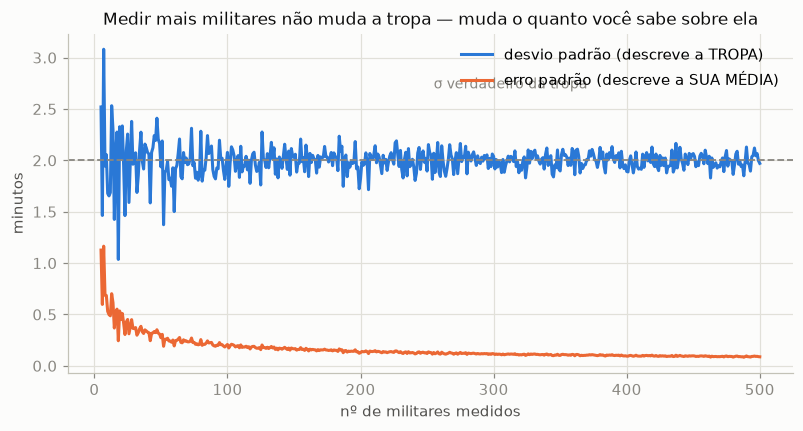

Azul: oscila em torno de 2,0 e fica lá. É a tropa.
Laranja: desce para zero. É a sua incerteza — e ela É reduzível, medindo mais gente.


In [19]:
# --- Os dois lado a lado, conforme o efetivo medido cresce ---
efetivos = np.arange(5, 501)
rng = np.random.default_rng(4)

sd_obs, se_obs = [], []
for n in efetivos:
    amostra = rng.normal(13.5, SIGMA_TROPA, n)
    sd_obs.append(amostra.std(ddof=1))
    se_obs.append(amostra.std(ddof=1) / np.sqrt(n))

plt.figure(figsize=(8.5, 4))
plt.plot(efetivos, sd_obs, color=COR["media"],   label="desvio padrão (descreve a TROPA)")
plt.plot(efetivos, se_obs, color=COR["mediana"], label="erro padrão (descreve a SUA MÉDIA)")
plt.axhline(SIGMA_TROPA, color="#898781", linestyle="--", linewidth=1.2)
plt.annotate("σ verdadeiro da tropa", xy=(255, SIGMA_TROPA + 0.7), color="#898781", fontsize=9)
plt.title("Medir mais militares não muda a tropa — muda o quanto você sabe sobre ela",
          color="#0b0b0b", fontsize=11)
plt.xlabel("nº de militares medidos")
plt.ylabel("minutos")
plt.legend(frameon=False)
plt.show()

print("Azul: oscila em torno de 2,0 e fica lá. É a tropa.")
print("Laranja: desce para zero. É a sua incerteza — e ela É reduzível, medindo mais gente.")

---
# ⑥ Decisão: o que reportar ao comando

| A pergunta real é... | Reporte | Por quê |
|---|---|---|
| quão parecidos são os militares | **desvio padrão** | está na unidade dos dados e é o padrão universal |
| comparar variabilidade entre **variáveis diferentes** | **CV (%)** | adimensional (§4.1) |
| há suspeita de **erro de digitação / outlier** | **IQR** ou **MAD** | não são destruídos por um ponto (§2.3) |
| **quantos ficam de fora** do critério | **percentil** ou média + k·σ | a decisão está na cauda (§4.3) |
| propagar incerteza por **várias etapas** | **variância** (soma) e depois a raiz | só ela é aditiva (§2.1) |
| quanto confio na **minha média** | **erro padrão** | descreve a estimativa, não a tropa (§5) |

### Três frases para levar

1. **A soma dos desvios é sempre zero** — a variância existe para contornar isso, e ela escolheu
   a mesma régua (o quadrado) que definiu a média.
2. **Variâncias se somam, desvios padrão não.** Daí sai a regra do √n e toda a propagação de erro.
3. **Média sozinha é meia verdade.** Sempre reporte centro **e** dispersão — e, se a decisão for
   cara, reporte a cauda.

---
# ⑦ Exercícios

**Exercício 1 — Preveja antes de rodar.**

O Pelotão Alfa tem desvio padrão ≈ 0,24 min. Suponha que **todos** os 12 militares treinem e
melhorem **exatamente 1 minuto** cada um.

1. O que acontece com a **média**?
2. O que acontece com o **desvio padrão**?
3. E se, em vez disso, todos os tempos fossem **multiplicados por 2**?

In [20]:
# EXERCÍCIO 1 — rode e compare com a sua previsão
print(f"{'':<22} | {'média':>7} | {'desvio':>7}")
print("-" * 42)
print(f"{'original':<22} | {alfa.mean():>7.3f} | {alfa.std(ddof=1):>7.3f}")
print(f"{'todos -1 minuto':<22} | {(alfa - 1).mean():>7.3f} | {(alfa - 1).std(ddof=1):>7.3f}")
print(f"{'todos × 2':<22} | {(alfa * 2).mean():>7.3f} | {(alfa * 2).std(ddof=1):>7.3f}")

print("\nRegra geral: SOMAR uma constante desloca o centro e não mexe na dispersão.")
print("MULTIPLICAR por uma constante mexe nos dois, na mesma proporção.")

                       |   média |  desvio
------------------------------------------
original               |  13.500 |   0.237
todos -1 minuto        |  12.500 |   0.237
todos × 2              |  27.000 |   0.475

Regra geral: SOMAR uma constante desloca o centro e não mexe na dispersão.
MULTIPLICAR por uma constante mexe nos dois, na mesma proporção.


**Exercício 2 — Mude um parâmetro.**

Na célula abaixo, mude `N_MILITARES` (comece com 3, depois 5, 20, 100).
Pergunta: a partir de que tamanho de amostra a diferença entre dividir por `n` e por `n − 1`
deixa de ter importância prática para você? Isso justifica ignorar o `ddof` em pelotões de 12?

In [21]:
# EXERCÍCIO 2 — mude o N_MILITARES e rode de novo
N_MILITARES = 3   # <-- MUDE AQUI

rng_ex2 = np.random.default_rng(0)
amostras_ex2 = rng_ex2.normal(13.0, 2.0, size=(40_000, N_MILITARES))

v0 = amostras_ex2.var(axis=1, ddof=0).mean()
v1 = amostras_ex2.var(axis=1, ddof=1).mean()

print(f"com n = {N_MILITARES}:")
print(f"  variância verdadeira    : 4.000")
print(f"  estimada com ddof=0     : {v0:.3f}   (erro de {(v0/4-1)*100:+.1f}%)")
print(f"  estimada com ddof=1     : {v1:.3f}   (erro de {(v1/4-1)*100:+.1f}%)")

com n = 3:
  variância verdadeira    : 4.000
  estimada com ddof=0     : 2.676   (erro de -33.1%)
  estimada com ddof=1     : 4.014   (erro de +0.3%)


**Exercício 3 — Conserte o erro (conceitual, não de sintaxe).**

A célula abaixo estima quanto tempo reservar de pista para uma patrulha de **4 trechos**.
Ela roda sem erro e devolve um número **errado e perigoso** — errado para o lado que faz o
comando planejar folga demais.

Descubra o erro e corrija. *(Dica: releia a §2.1 e pergunte-se o que realmente se soma.)*
A conferência por simulação no final da célula está correta — use-a para validar.

In [22]:
# EXERCÍCIO 3 — o resultado sai, mas está errado. Conserte.
tempos_medios  = np.array([18.0, 9.0, 6.0, 22.0])   # min, por trecho
desvios_trecho = np.array([ 3.0, 1.0, 2.0,  4.0])   # min, por trecho

tempo_total_medio = tempos_medios.sum()
desvio_total      = desvios_trecho.sum()            # <-- o erro está NESTA linha

print(f"tempo médio total ....: {tempo_total_medio:.2f} min")
print(f"desvio padrão total ..: {desvio_total:.2f} min")
print(f"planejamento (média + 2 desvios): {tempo_total_medio + 2 * desvio_total:.2f} min")

# --- conferência por simulação (não mexa) ---
rng_ex3 = np.random.default_rng(11)
sim = np.column_stack([rng_ex3.normal(m, s, 100_000) for m, s in zip(tempos_medios, desvios_trecho)]).sum(axis=1)
print(f"\nconferência · desvio padrão real do total ....: {sim.std(ddof=1):.2f} min")
print(f"conferência · percentil 97,5 dos totais .....: {np.percentile(sim, 97.5):.2f} min")

tempo médio total ....: 55.00 min
desvio padrão total ..: 10.00 min
planejamento (média + 2 desvios): 75.00 min

conferência · desvio padrão real do total ....: 5.47 min
conferência · percentil 97,5 dos totais .....: 65.80 min


**Exercício 4 — Escolha a medida (sem código).**

Para cada situação, diga **qual medida de dispersão** você usaria e **por quê** em uma frase:

1. Comparar se o pelotão é mais heterogêneo em **peso** ou em **tempo de corrida**.
2. Um relatório veio com um militar de **1,90 s** na corrida de 3 km (erro de digitação óbvio) e
   você precisa de um número **agora**, sem tempo de limpar a base.
3. Estimar a variabilidade do tempo total de uma operação com **6 fases** independentes.
4. Dizer ao comando quanta confiança ele pode ter na afirmação "o tempo médio da companhia é 13,4 min".
5. Definir o tempo de reserva da pista de forma que **90% dos militares** terminem dentro dele.

**Exercício 5 — Interprete (discussão em grupo).**

Dois pelotões, mesmo efetivo:

| | média | desvio padrão |
|---|---|---|
| **Charlie** | 13,0 min | 0,4 min |
| **Delta** | 12,4 min | 2,6 min |

1. Qual pelotão tem o **melhor desempenho médio**? Qual você **empregaria** numa missão em que
   todos precisam terminar em 13,5 min? Justifique com números, não com opinião.
2. O comandante do Delta argumenta que o desvio alto é porque ele tem "os melhores e os piores".
   Que **um gráfico** você pediria a ele para verificar isso? (Módulo 3.)
3. Se você soubesse que o Delta tem **2 militares em recuperação de lesão**, o que mudaria no seu
   relatório — e qual medida de dispersão você passaria a usar?

---
## Resumo do módulo

| Medida | O que é | Ponto forte | Ponto fraco |
|---|---|---|---|
| **Amplitude** (máx − mín) | distância entre extremos | trivial de explicar | usa só 2 dados; piora com n |
| **Desvio absoluto médio** | média de \|x − média\| | intuitivo, na unidade dos dados | não se soma; menos preciso |
| **Variância** | média de (x − média)² | **aditiva** — a base de tudo | unidade ao quadrado |
| **Desvio padrão** | raiz da variância | unidade dos dados, universal | destruído por 1 outlier |
| **IQR / MAD** | dispersão robusta | resiste a erros de registro | descarta informação |
| **CV (%)** | desvio ÷ média | compara variáveis diferentes | só com zero absoluto |
| **Erro padrão** | desvio ÷ √n | mede a confiança na **estimativa** | não descreve a tropa |

- A soma dos desvios é **sempre zero** — por isso elevamos ao quadrado.
- **Variâncias se somam; desvios padrão não.** Daí a regra do **√n**.
- `n − 1` corrige o viés da **variância** (não o do desvio padrão) — e `numpy` e `pandas`
  discordam no padrão: **escreva o `ddof`**.

➡️ **Próximo módulo:** média e desvio padrão **juntos** ainda não bastam. Conjuntos com os mesmos
dois números podem ter formatos radicalmente diferentes — e o formato é o que decide se as suas
fórmulas valem. Isso é a **forma da distribuição** (Módulo 3).